# PCA on the Breast Cancer Dataset

Reduces the 30 features to a small number of principal components so the data can be fed into the vqc with only a few qubits.

## Setup

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Load and scale the data

X holds the 30 features, y the labels (0 = malignant, 1 = benign). Features are standardized first, since PCA is sensitive to scale.

In [22]:
data = load_breast_cancer()
X = data.data            # 569 tumors × 30 features (the inputs)
y = data.target          # 0 = malignant, 1 = benign (the answers)

X_scaled = StandardScaler().fit_transform(X)
X_scaled.shape           # should print (569, 30)

(569, 30)

## Fit PCA on all components

Fitting PCA with all components to measure how much variance each one captures, before deciding how many to keep.

In [23]:
pca_full = PCA().fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

## Cumulative variance table

In [24]:
pcs = [f"PC{i+1}" for i in range(len(explained))]
table = pd.DataFrame({"variance kept": explained, "cumulative kept": cumulative}, index=pcs)
table.head()

,variance kept,cumulative kept
PC1,0.442720,0.442720
PC2,0.189712,0.632432
PC3,0.093932,0.726364
PC4,0.066021,0.792385
PC5,0.054958,0.847343


## Explained variance plot

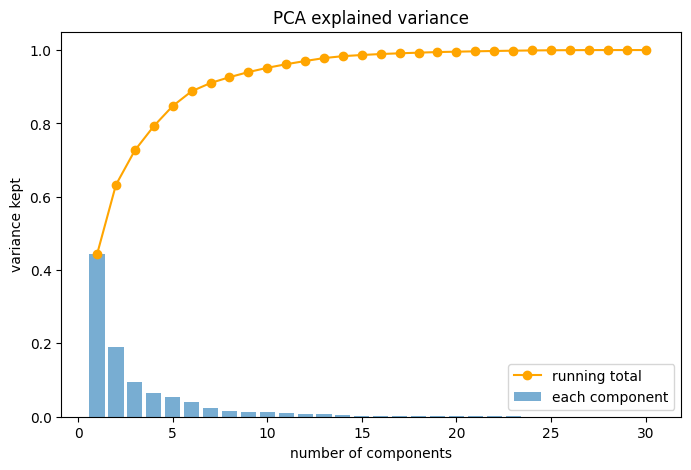

In [25]:
plt.figure(figsize=(8, 5))
xs = np.arange(1, len(explained) + 1)

plt.bar(xs, explained, alpha=0.6, label="each component")
plt.plot(xs, cumulative, color="orange", marker="o", label="running total")

plt.xlabel("number of components")
plt.ylabel("variance kept")
plt.title("PCA explained variance")
plt.legend()
plt.show()

## Reduce to 2 and 4 components

Transforming the data down to 2 and 4 components and summing the variance each keeps.

In [26]:
pca2 = PCA(n_components=2).fit(X_scaled)
pca4 = PCA(n_components=4).fit(X_scaled)

var2 = pca2.explained_variance_ratio_.sum()
var4 = pca4.explained_variance_ratio_.sum()

print("2 components keep:",var2, "%")
print("4 components keep:", var4, "%")

2 components keep: 0.6324320765155945 %
4 components keep: 0.7923850582446098 %
